In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [2]:
# let's have a look at the data scraped from web of science

In [3]:
# there's considerable range in our bs values; this may actually be an informative about
# the different entitites[fields, countries, genders, institutions, journals ..]
# for instance, we can see that the minimum index for neuroscience is more than double the minimum in physics
# we can also notice below how the highest author indices are much larger in physics than neuroscience!

In [4]:
neuro_df = pd.read_csv('/Users/mococomac/PycharmProjects/bsFactor/fields/neuroscience/outputs/neuroscience_bs_indices.csv')
physi_df = pd.read_csv('/Users/mococomac/PycharmProjects/bsFactor/fields/physics/outputs/physics_bs_indices.csv')

In [5]:
print("there's " + str(neuro_df.shape[0]) + ' neuroscience indices, with values from ' +str(np.round(neuro_df['BS_Index'].min(),4)) + ' to ' + str(neuro_df['BS_Index'].max()) + ', from ' + str(len(neuro_df["Country"].unique())) + ' countries and ' + str(len(neuro_df["Author"].unique())) + ' authors with '+ str(np.round(neuro_df.groupby('Author')['BS_Index'].count().mean()))+' papers on average')
print("there's " + str(physi_df.shape[0]) + ' physics indices, with values from ' +str(np.round(physi_df['BS_Index'].min(),4)) + ' to ' + str(physi_df['BS_Index'].max())+ ', from ' + str(len(physi_df["Country"].unique())) + ' countries and ' + str(len(physi_df["Author"].unique())) + ' authors with '+str(np.round(physi_df.groupby('Author')['BS_Index'].count().mean()))+' papers on average')

there's 174025 neuroscience indices, with values from 0.0257 to 132.964, from 37 countries and 4605 authors with 38.0 papers on average
there's 55159 physics indices, with values from 0.0107 to 127.39, from 13 countries and 1509 authors with 37.0 papers on average


In [6]:
# in case you're wondering who's best and worst
neuro_df.groupby('Author')['BS_Index'].median().sort_values(ascending=False)

Author
Yfanti, E          10.547500
Barinaga, M         9.996200
Batista, AM         8.737000
Bae, H              8.594500
Soto-sanchez, C     8.333000
                     ...    
Braun, U            0.275286
Moonen, G           0.274125
Yeung, AW           0.259241
Betzel, RF          0.244760
Ganguly, G          0.128000
Name: BS_Index, Length: 4605, dtype: float64

In [7]:
physi_df.groupby('Author')['BS_Index'].median().sort_values(ascending=False)

Author
Lloyd, SL         28.244000
Geiser, A         17.497000
Womersley, WJ     12.742000
Lethuillier, M     8.394000
Robutti, E         8.275500
                    ...    
De, N              0.223489
Meyer, JP          0.164389
Ekelof, T          0.139000
Nakamura, K        0.127000
Di, E              0.089895
Name: BS_Index, Length: 1509, dtype: float64

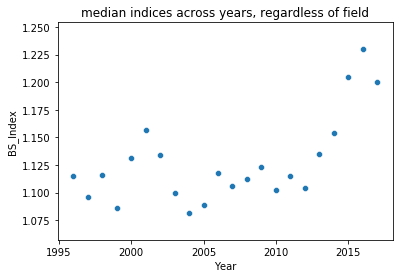

In [8]:
# scatterplot to eyeball how the indices have evolved across years

sns.scatterplot(pd.concat([neuro_df,physi_df]).groupby(['Year'])['BS_Index'].median()).set(title='median indices across years, regardless of field');

In [9]:
# let's plot some histograms

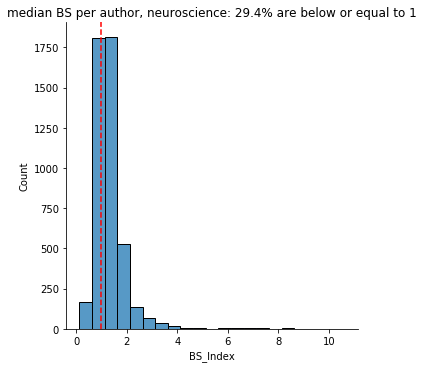

In [10]:
p = sns.displot(neuro_df.groupby('Author').median(), x="BS_Index",binwidth=0.5);

virtuous_neuro_authors = np.round((neuro_df.groupby('Author').median()['BS_Index']<=1).sum()/len(neuro_df["Author"].unique()),3)
virtuous_neuro_authors *= 100

p.set(title='median BS per author, neuroscience: ' + str(virtuous_neuro_authors) + '% are below or equal to 1')
plt.axvline(x=1, color='red', linestyle='--', label='Vertical Line');

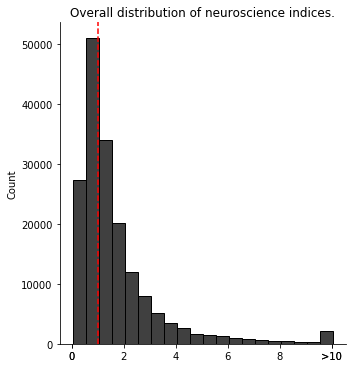

In [11]:
neuro_virtuous = np.round((neuro_df['BS_Index']<=1).sum()/len(neuro_df['BS_Index'])*100,2)

threshold = 10

# Truncate values beyond the threshold
truncated_data = np.where(neuro_df["BS_Index"] > threshold, threshold, neuro_df["BS_Index"])

sns.displot(truncated_data,binwidth=0.5,color='black').set(title='Overall distribution of neuroscience indices.')
plt.axvline(x=1, color='red', linestyle='--', label='Vertical Line')

xticks = list(plt.xticks()[0])
# Set the last tick to be '>10'
xticks[0] = 0
xticks[-1] = threshold
xtick_labels = [str(int(tick)) if tick < threshold else '>10' for tick in xticks]

# Set the new tick locations and labels
plt.xticks(xticks, xtick_labels);

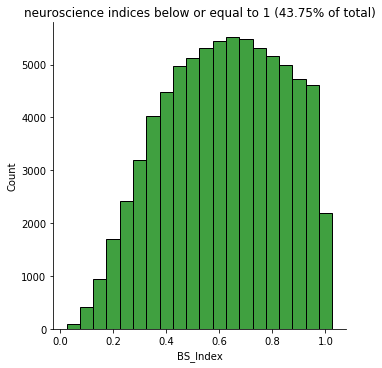

In [12]:
# here we're plotting 'positive indices' i.e. with val = or < 1
p = sns.displot(neuro_df.loc[neuro_df['BS_Index']<=1], x="BS_Index",binwidth=0.05, color='green');
p.set(title='neuroscience indices below or equal to 1 ('+str(neuro_virtuous)+'% of total)');

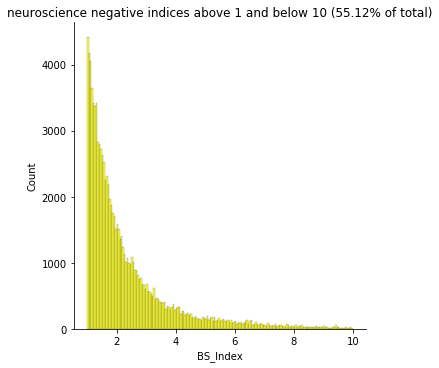

In [13]:
# here we're plotting 'negative indices' i.e. with val > 1 {binwidth .05 from 1 to 10}
# then just a bin for higher than that
p = sns.displot(neuro_df.loc[(neuro_df['BS_Index']>1) & (neuro_df['BS_Index']<10)], x="BS_Index",binwidth=.05, color='yellow');
p.set(title='neuroscience negative indices above 1 and below 10 (' + str(np.round((((neuro_df['BS_Index']>1) & (neuro_df['BS_Index']<10)).sum()/neuro_df.shape[0]) * 100,2)) + '% of total)');

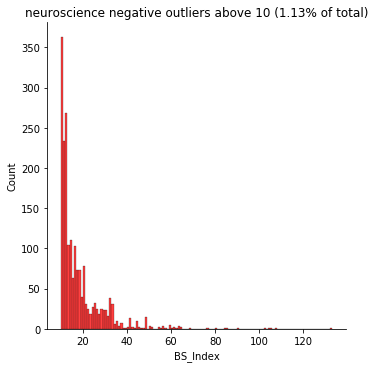

In [14]:
p = sns.displot(neuro_df.loc[(neuro_df['BS_Index']>10)], x="BS_Index",binwidth=1,color='red');
p.set(title='neuroscience negative outliers above 10 (' + str(np.round(((neuro_df['BS_Index']>10).sum()/neuro_df.shape[0]) * 100,2)) + '% of total)');

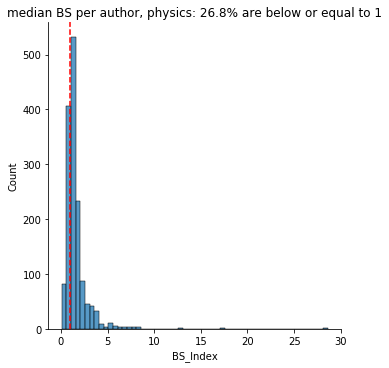

In [15]:
p = sns.displot(physi_df.groupby('Author').median(), x="BS_Index",binwidth=0.5);

virtuous_physi_authors = np.round((physi_df.groupby('Author').median()['BS_Index']<=1).sum()/len(physi_df["Author"].unique()),3)
virtuous_physi_authors *= 100

p.set(title='median BS per author, physics: ' + str(virtuous_physi_authors) + '% are below or equal to 1');
plt.axvline(x=1, color='red', linestyle='--', label='Vertical Line');

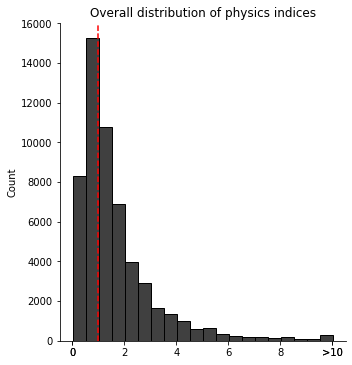

In [16]:
physi_virtuous = np.round((physi_df['BS_Index']<=1).sum()/len(physi_df['BS_Index'])*100,2)

truncated_data2 = np.where(physi_df["BS_Index"] > threshold, threshold, physi_df["BS_Index"])


sns.displot(truncated_data2,binwidth=0.5,color='black').set(title='Overall distribution of physics indices');
plt.axvline(x=1, color='red', linestyle='--', label='Vertical Line');

xticks = list(plt.xticks()[0])
# Set the last tick to be '>10'
xticks[0] = 0
xticks[-1] = threshold
xtick_labels = [str(int(tick)) if tick < threshold else '>10' for tick in xticks]

# Set the new tick locations and labels
plt.xticks(xticks, xtick_labels);

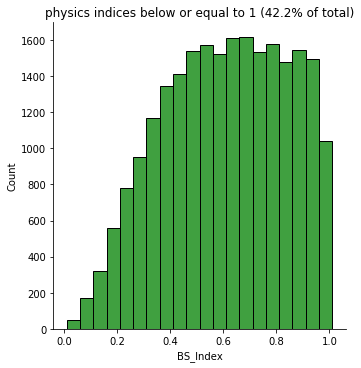

In [17]:
# here we're plotting 'positive indices' i.e. with val = or < 1
p = sns.displot(physi_df.loc[physi_df['BS_Index']<=1], x="BS_Index",binwidth=0.05, color='green');
p.set(title='physics indices below or equal to 1 ('+str(physi_virtuous)+'% of total)');

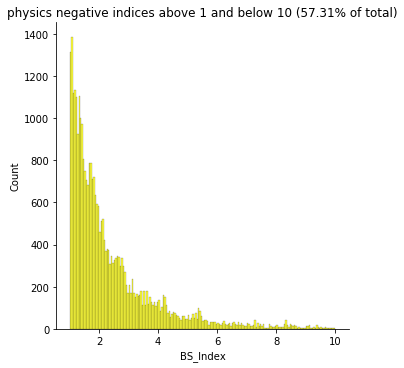

In [18]:
# here we're plotting 'negative indices' i.e. with val > 1 {binwidth .05 from 1 to 10}
# then just a bin for higher than that
p = sns.displot(physi_df.loc[(physi_df['BS_Index']>1) & (physi_df['BS_Index']<10)], x="BS_Index",binwidth=.05, color='yellow');
p.set(title='physics negative indices above 1 and below 10 (' + str(np.round((((physi_df['BS_Index']>1) & (physi_df['BS_Index']<10)).sum()/physi_df.shape[0]) * 100,2)) + '% of total)');

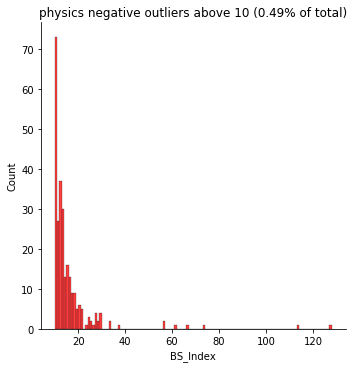

In [19]:
p = sns.displot(physi_df.loc[(physi_df['BS_Index']>10)], x="BS_Index",binwidth=1,color='red');
p.set(title='physics negative outliers above 10 (' + str(np.round(((physi_df['BS_Index']>10).sum()/physi_df.shape[0]) * 100,2)) + '% of total)');